# Exploratory Data Analysis Workshop
## The Bridge Between Raw Data and Meaningful Insight

**Dataset:** Respiratory Patient Data (OMOP CDM Synthetic Extract)

---

### Learning Objectives

By the end of this workshop, you will be able to:
1. Distinguish between seven types of analytical questions and understand their EDA requirements
2. Apply the four dimensions of exploration (distributional, relational, structural, comparative)
3. Identify data quality issues, patterns, and limitations before modeling
4. Interpret findings and distinguish signal from artifact
5. Determine appropriate next steps based on EDA outcomes

---
## Setup and Imports

Run the cell below to import the required libraries.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
plt.style.use('seaborn-v0_8-whitegrid')

sns.set(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)

%matplotlib inline

# Initialize random number generator for reproducibility, Panda's utilizes NumPy module not "random"
np.random.seed(42)

print("Libraries loaded successfully!")

Libraries loaded successfully!


---
## Part 1: Data Loading and Initial Inspection

### About the Dataset

This dataset contains synthetic patient records extracted from an OMOP Common Data Model (from OHDSI). The records represent patients with respiratory observations, including:
- Patient demographics (age, gender, race, ethnicity)
- Visit information (dates, type, conditions)
- Vital signs (temperature, oxygen saturation, heart rate, etc.)
- Vaccination history
- Patient outcomes

## Intial Analysis
With any dataset, you'll want to perform an initial "exploratory" data analysis to help you understand the structure, patterns, and relationships. 

A few goals:
1. **Data Summarization** - gain an quick overview of the dataset
   - **Shape and size of data:** Number of rows, columns, and unique values.
   - **Descriptive statistics:** Mean, median, standard deviation, percentiles.
2. **Data Cleaning** - ensure data quality
   - **Handling missing values:** Identify and impute (mean/median/mode) or remove missing entries.
   - **Removing duplicates:** Eliminate redundant rows or records.
   - **Correcting data types:** Convert data to appropriate formats (e.g., dates, numbers, categories).
   - **Dealing with outliers:** Detect and decide whether to remove or transform extreme values.
3. **Feature Engineering - add additional features/variables to support analysis

In [3]:
# Load data
df = pd.read_csv("data.csv")

In [4]:
# Perform basic exploratory data analysis
# df.head(n)  # top n rows, n defaults to 5
# df.tail(n)  # last n rows
# df.sample(5) # sample x rows
df

,person_id,birth_datetime,race_source_value,ethnicity_source_value,gender_source_value,visit_occurrence_id,visit_start_date,visit_end_date,visit_type,condition,observation_source,age_at_visit_years,measurement_Date,body_height_cm,bmi,body_temperature_c,body_weight_kg,systolic,diastolic,heart_rate_bpm,oxygen_saturation_percent,respiratory_rate_per_minute,flu_last_administered,tdap_last_administered,mmr_last_administered,polio_last_administered,deceased
0,1,1958-12-02,white,nonhispanic,F,1,2020-03-11,2020-04-01,Inpatient Visit,Dyspnea:Pneumonia:Respiratory distress:Wheezing,Suspected COVID-19,61.27,2020-03-11,NaN,NaN,40.2,71.3,132.0,81.0,178.9,84.8,37.0,2019-09-11,2010-12-02,1962-12-02,1962-12-02,Y
1,2,1945-10-02,white,nonhispanic,F,28,2020-05-07,2020-05-07,Outpatient Visit,Viral sinusitis,NaN,74.60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-12-04,2017-10-02,1949-10-02,1949-10-02,N
2,3,1968-04-20,white,nonhispanic,M,188,2020-03-15,2020-03-15,Outpatient Visit,Sore throat symptom:Dyspnea:Wheezing,Suspected COVID-19,51.90,2020-03-14,NaN,NaN,42.2,91.9,108.0,76.0,57.1,78.4,32.1,2019-11-19,2010-04-20,1972-04-20,1972-04-20,N
3,5,1988-08-09,white,nonhispanic,F,198,1992-08-15,1992-08-29,Outpatient Visit,Perennial allergic rhinitis,NaN,4.02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1991-10-24,NaN,1992-08-09,1992-08-09,N
4,5,1988-08-09,white,nonhispanic,F,206,2020-03-10,2020-03-10,Outpatient Visit,Cough,Suspected COVID-19,31.58,2020-03-10,NaN,NaN,41.6,74.4,130.0,84.0,132.8,88.4,14.4,2019-10-23,2010-08-09,1992-08-09,1992-08-09,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156025,124148,2017-08-11,white,nonhispanic,M,3139386,2020-03-08,2020-03-08,Outpatient Visit,Cough,Suspected COVID-19,2.57,2020-03-08,NaN,NaN,39.4,12.2,108.0,83.0,170.0,84.8,32.6,2019-12-27,NaN,2018-08-11,2018-02-11,N
156026,124149,1948-12-16,black,nonhispanic,F,3139391,2019-10-23,2019-10-23,Outpatient Visit,Viral sinusitis,NaN,70.85,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-12-08,2010-12-16,1952-12-16,1952-12-16,N
156027,124149,1948-12-16,black,nonhispanic,F,3139397,2020-02-14,2020-03-06,Inpatient Visit,Acute respiratory failure:Pneumonia:Respirator...,Suspected COVID-19,71.16,2020-02-14,NaN,NaN,39.0,77.1,119.0,73.0,149.8,87.5,13.6,2019-12-12,2010-12-16,1952-12-16,1952-12-16,N
156028,124149,1948-12-16,black,nonhispanic,F,3139393,2020-03-17,2020-03-17,Outpatient Visit,Viral sinusitis,NaN,71.25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-12-04,2010-12-16,1952-12-16,1952-12-16,N


In [5]:
print("Dataframe shape:",df.shape)
print(df.info())

Dataframe shape: (156030, 27)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156030 entries, 0 to 156029
Data columns (total 27 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    156030 non-null  int64  
 1   birth_datetime               156030 non-null  object 
 2   race_source_value            156030 non-null  object 
 3   ethnicity_source_value       156030 non-null  object 
 4   gender_source_value          156030 non-null  object 
 5   visit_occurrence_id          156030 non-null  int64  
 6   visit_start_date             156030 non-null  object 
 7   visit_end_date               156030 non-null  object 
 8   visit_type                   156030 non-null  object 
 9   condition                    156030 non-null  object 
 10  observation_source           78197 non-null   object 
 11  age_at_visit_years           156030 non-null  float64
 12  measurement_Date            

In [6]:
# Convert date fields
for c in ["visit_start_date", "visit_end_date", "birth_datetime", "measurement_Date","flu_last_administered","tdap_last_administered","mmr_last_administered","polio_last_administered"]:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors="coerce")

In [7]:
# Examine missing fields
n_rows = len(df)

missing_table = (   # create a new dataframe
    df.isna()
      .agg(['sum', 'mean'])
      .T
      .rename(columns={'sum': 'missing_count', 'mean': 'missing_percent'})
)

missing_table['missing_percent'] = (missing_table['missing_percent'] * 100).round(2)
missing_table['non_missing_count'] = n_rows - missing_table['missing_count']
missing_table['dtype'] = df.dtypes.astype(str)

missing_table = (
    missing_table
      .reset_index(names='column')
      .sort_values(by=['missing_percent', 'column'], ascending=[False, True])
      .set_index('column')
)

missing_table

,missing_count,missing_percent,non_missing_count,dtype
column,,,,
bmi,153062.0,98.10,2968.0,float64
body_height_cm,152974.0,98.04,3056.0,float64
oxygen_saturation_percent,79221.0,50.77,76809.0,float64
observation_source,77833.0,49.88,78197.0,object
body_weight_kg,76295.0,48.90,79735.0,float64
heart_rate_bpm,76295.0,48.90,79735.0,float64
respiratory_rate_per_minute,76295.0,48.90,79735.0,float64
diastolic,76285.0,48.89,79745.0,float64
systolic,76285.0,48.89,79745.0,float64


**Question:** What patterns do you notice in the missing data? Which columns have the most missing values, and why might that be?

In [8]:
# Create a column for visit length - ignoring visit type 
los = (df["visit_end_date"] - df["visit_start_date"]).dt.days
df["length_of_stay_days"] = los.clip(lower=0)


# Modify labels for deceased column
df["deceased_flag"] = df["deceased"].map({"Y": "Deceased", "N": "Alive"}).fillna("Unknown").astype("category")

# columns for year and month
df["visit_year"] = df["visit_start_date"].dt.year
df["visit_month"] = df["visit_start_date"].dt.to_period("M").astype(str)

df['gender_source_value'] = df['gender_source_value'].astype('category')
df['race_source_value'] = df['race_source_value'].astype('category')
df['ethnicity_source_value'] = df['ethnicity_source_value'].astype('category')

In [9]:
# Descriptive Statistics for Numeric Columns
df.describe()    

,person_id,birth_datetime,visit_occurrence_id,visit_start_date,visit_end_date,age_at_visit_years,measurement_Date,body_height_cm,bmi,body_temperature_c,body_weight_kg,systolic,diastolic,heart_rate_bpm,oxygen_saturation_percent,respiratory_rate_per_minute,flu_last_administered,tdap_last_administered,mmr_last_administered,polio_last_administered,length_of_stay_days,visit_year
count,156030.000000,156030,1.560300e+05,156030,156030,156030.000000,88854,3056.000000,2968.000000,85945.00000,79735.000000,79745.000000,79745.000000,79735.000000,76809.000000,79735.000000,156030,124884,154223,155802,156030.000000,156030.000000
mean,62077.565180,1971-12-17 22:48:31.840030784,1.566862e+06,2009-10-28 18:34:32.924437760,2009-12-29 12:17:16.046914048,37.864144,2019-08-24 19:06:15.582415872,163.141132,27.243194,39.70430,73.216472,121.312672,80.420540,123.435253,82.008590,25.559516,2009-04-26 01:44:21.134397184,2007-07-04 19:40:22.484866048,1975-06-06 06:02:43.726551808,1975-08-21 00:05:41.602803584,61.737999,2009.484920
min,1.000000,1909-06-24 00:00:00,1.000000e+00,1909-09-17 00:00:00,1909-09-17 00:00:00,0.010000,1919-05-11 00:00:00,50.600000,12.700000,36.10000,1.800000,97.000000,67.000000,50.000000,66.100000,12.000000,1908-10-06 00:00:00,1921-06-24 00:00:00,1910-07-21 00:00:00,1909-09-11 00:00:00,0.000000,1909.000000
25%,30962.000000,1953-03-09 00:00:00,7.822792e+05,2007-05-16 06:00:00,2007-10-26 00:00:00,16.160000,2020-02-28 00:00:00,159.700000,27.200000,38.50000,66.800000,113.000000,76.000000,85.100000,78.500000,18.200000,2006-10-14 00:00:00,2009-09-19 18:00:00,1956-12-04 00:00:00,1957-01-03 00:00:00,0.000000,2007.000000
50%,62111.500000,1971-06-14 00:00:00,1.566715e+06,2020-02-22 00:00:00,2020-02-24 00:00:00,36.070000,2020-03-05 00:00:00,167.700000,28.000000,39.70000,78.000000,120.000000,80.000000,122.000000,82.000000,25.500000,2019-09-13 00:00:00,2013-06-11 00:00:00,1975-01-21 00:00:00,1975-04-08 00:00:00,0.000000,2020.000000
75%,93253.500000,1994-04-29 00:00:00,2.358876e+06,2020-03-07 00:00:00,2020-03-09 00:00:00,57.170000,2020-03-10 00:00:00,176.100000,29.800000,40.90000,87.400000,128.000000,84.000000,161.500000,85.500000,32.700000,2019-11-07 00:00:00,2016-11-04 00:00:00,1997-09-01 12:00:00,1998-01-02 00:00:00,0.000000,2020.000000
max,124150.000000,2020-04-21 00:00:00,3.139398e+06,2020-05-26 00:00:00,2020-05-27 00:00:00,110.730000,2020-05-26 00:00:00,198.700000,53.300000,42.20000,181.200000,201.000000,121.000000,200.000000,89.000000,40.000000,2019-12-31 00:00:00,2020-05-25 00:00:00,2020-05-19 00:00:00,2020-05-25 00:00:00,38325.000000,2020.000000
std,35919.884529,NaN,9.067587e+05,NaN,NaN,25.103145,NaN,23.250398,4.428474,1.42849,22.775382,13.423653,6.791986,43.523960,4.050973,8.243366,NaN,NaN,NaN,NaN,995.266731,19.479078


In [10]:
# for categorical columns
df.describe(include=['object','category'])  

,race_source_value,ethnicity_source_value,gender_source_value,visit_type,condition,observation_source,deceased,deceased_flag,visit_month
count,156030,156030,156030,156030,156030,78197,156030,156030,156030
unique,5,2,2,3,4185,21,2,2,1295
top,white,nonhispanic,M,Outpatient Visit,Cough,Suspected COVID-19,N,Alive,2020-03
freq,131136,138838,78691,134954,33292,73304,139602,139602,62667


In [11]:
# Create an alternate view of the conditions, placingin into a separate tidy dataframe
import re

# robust split on ":" allowing extra spaces; keep NaN if empty
def split_conditions(s):
    if pd.isna(s) or str(s).strip() == "":
        return []
    # split on ":" with optional surrounding spaces
    parts = re.split(r"\s*:\s*", str(s))
    # normalize: strip, drop empties, lower (or title-case if you prefer)
    parts = [p.strip() for p in parts if p and p.strip()]
    return parts

# apply once to create a list-typed column
df["condition_list"] = df["condition"].map(split_conditions)

cond_long = (
    df[["visit_occurrence_id", "person_id", "visit_start_date"]]
      .assign(condition_item=df["condition_list"])
      .explode("condition_item", ignore_index=True)
)

# drop rows where no condition exists after cleaning
cond_long = cond_long.dropna(subset=["condition_item"])

# (optional) dedupe within visit in case the same condition appears twice
cond_long = cond_long.drop_duplicates(subset=["visit_occurrence_id", "condition_item"])
cond_long

,visit_occurrence_id,person_id,visit_start_date,condition_item
0,1,1,2020-03-11,Dyspnea
1,1,1,2020-03-11,Pneumonia
2,1,1,2020-03-11,Respiratory distress
3,1,1,2020-03-11,Wheezing
4,28,2,2020-05-07,Viral sinusitis
...,...,...,...,...
249048,3139398,124150,2020-03-07,Wheezing
249049,3139398,124150,2020-03-07,Cough
249050,3139398,124150,2020-03-07,Respiratory distress
249051,3139398,124150,2020-03-07,Pneumonia


In [12]:
# For outpatient visits, assume this is a data issue and the length should be 0
is_outpatient = df['visit_type'].astype(str).str.contains('outpatient', case=False, na=False)

# align dates, then recompute LOS as zero
df.loc[is_outpatient, 'visit_end_date'] = df.loc[is_outpatient, 'visit_start_date']
df.loc[is_outpatient, 'length_of_stay_days'] = 0

# remove any records where length_of_stay_days > 100
df = df[df["length_of_stay_days"] <= 100].copy()

---
## Part 2: Distributional Exploration

**Goal:** Examine individual variables to understand their scale, shape, and validity.

### The Seven Question Types

Before we explore, remember that the type of question determines the EDA approach:

| Type | Core Question | Example |
|------|--------------|--------|
| Descriptive | What happened? | What is the distribution of conditions? |
| Exploratory | What patterns exist? | Is there a relationship between temperature and O2 sat? |
| Inferential | Does this generalize? | Is the O2 sat difference statistically significant? |
| Predictive | What will happen? | Can we predict inpatient admission? |
| Prescriptive | What should we do? | What thresholds should trigger escalation? |
| Causal | What if we intervene? | Would earlier vaccination reduce severity? |
| Mechanistic | What process produces this? | How does symptom progression unfold? |

### Exercise 2.1: Demographic Distributions

Create frequency counts for the following categorical variables:
1. Gender (`gender_source_value`)
2. Race (`race_source_value`)
3. Ethnicity (`ethnicity_source_value`)

**Note:** For demographics, we should look at unique patients, not all visits (since one patient can have multiple visits).

In [13]:
# First, create a dataframe of unique patients
# YOUR CODE HERE
patients = df.drop_duplicates(subset=["person_id"]).copy()

print(f"Total unique patients: {len(patients)}")

Total unique patients: 98966


In [14]:
# Gender distribution
gender_counts = patients["gender_source_value"].value_counts(dropna=False)
print(gender_counts)

gender_source_value
M    49520
F    49446
Name: count, dtype: int64


In [15]:
# Race distribution
race_counts = patients["race_source_value"].value_counts(dropna=False)
print(race_counts)

race_source_value
white     83204
black      8333
asian      6841
native      480
other       108
Name: count, dtype: int64


In [16]:
# Ethnicity distribution
eth_counts = patients["ethnicity_source_value"].value_counts(dropna=False)
print(eth_counts)

ethnicity_source_value
nonhispanic    88011
hispanic       10955
Name: count, dtype: int64


### Exercise 2.2: Age Distribution

1. Calculate descriptive statistics for `age_at_visit_years`
2. Create a histogram of the age distribution
3. Create age groups (Pediatric: 0-18, Young Adult: 18-40, Middle Age: 40-65, Elderly: 65+)

In [17]:
# 1. Descriptive statistics for age
df["age_at_visit_years"].describe()


count    155972.000000
mean         37.856991
std          25.102684
min           0.010000
25%          16.160000
50%          36.050000
75%          57.160000
max         110.730000
Name: age_at_visit_years, dtype: float64

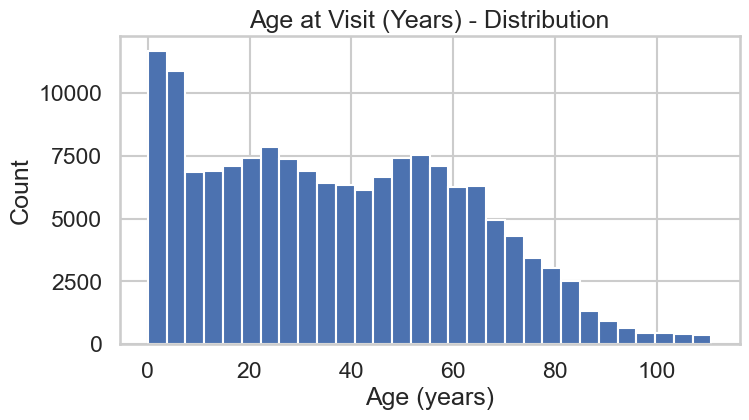

In [18]:
# 2. Histogram of age distribution
ages = df["age_at_visit_years"].dropna()

plt.figure(figsize=(8, 4))
plt.hist(ages, bins=30)
plt.title("Age at Visit (Years) - Distribution")
plt.xlabel("Age (years)")
plt.ylabel("Count")
plt.show()

In [19]:
# 3. Create age groups and show their distribution
bins = [0, 18, 40, 65, 120]
labels = ["Pediatric (0-18)", "Young Adult (18-40)", "Middle Age (40-65)", "Elderly (65+)"]

df["age_group"] = pd.cut(df["age_at_visit_years"], bins=bins, labels=labels, right=True, include_lowest=True)

age_group_counts = df["age_group"].value_counts(dropna=False)
print(age_group_counts)
print((age_group_counts / len(df) * 100).round(1))
# Hint: Use pd.cut() with bins=[0, 18, 40, 65, 100]


age_group
Middle Age (40-65)     46333
Pediatric (0-18)       42577
Young Adult (18-40)    41987
Elderly (65+)          25075
Name: count, dtype: int64
age_group
Middle Age (40-65)     29.7
Pediatric (0-18)       27.3
Young Adult (18-40)    26.9
Elderly (65+)          16.1
Name: count, dtype: float64


### Exercise 2.3: Condition Analysis

The `condition` column contains multiple conditions separated by colons (`:`).

1. Parse the conditions into individual items
2. Count the frequency of each condition
3. Create a bar chart of the top 10 conditions

In [20]:
# 1. Parse conditions (split by colon)
def split_conditions(s):
    if pd.isna(s) or str(s).strip() == "":
        return []
    parts = [p.strip() for p in str(s).split(":")]
    return [p for p in parts if p]

df["condition_list"] = df["condition"].map(split_conditions)

# 2. Explode and count
all_conditions = df["condition_list"].explode()
condition_counts = all_conditions.value_counts()

condition_counts.head(20)

condition_list
Cough                                                  63418
Chronic sinusitis                                      26760
Pneumonia                                              20436
Respiratory distress                                   19111
Dyspnea                                                18511
Wheezing                                               18511
Viral sinusitis                                        16223
Sore throat symptom                                    13163
Acute respiratory failure                               9124
Acute viral pharyngitis                                 8344
Acute bronchitis                                        7096
Nasal congestion                                        4324
Perennial allergic rhinitis with seasonal variation     2964
Perennial allergic rhinitis                             2935
Acute respiratory distress syndrome                     2445
Pulmonary emphysema                                     2127
Emphysema

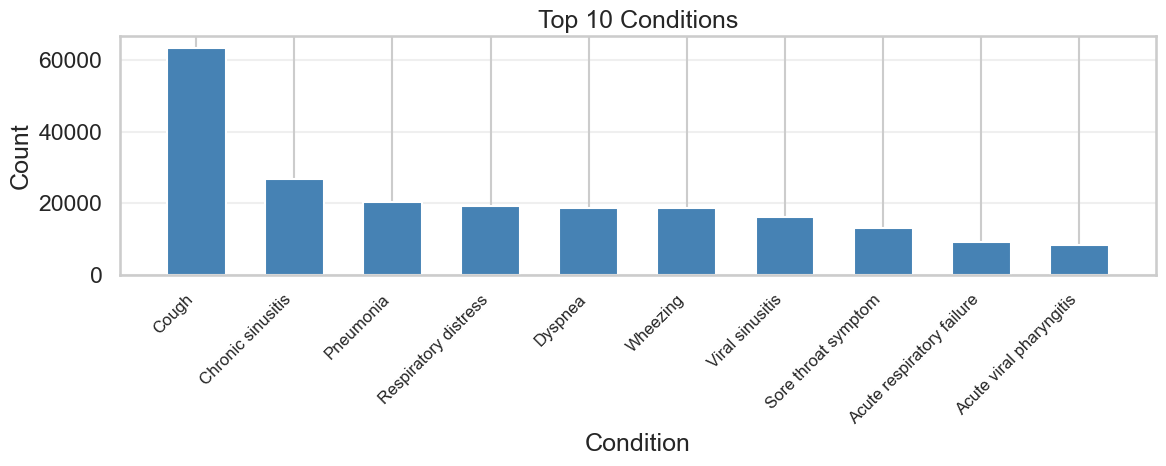

In [56]:
# 3. Bar chart of top 10 conditions
top10 = condition_counts.head(10)

plt.figure(figsize=(12, 5))
plt.bar(top10.index.astype(str), top10.values, color='steelblue', width=0.6)
plt.title("Top 10 Conditions")
plt.xlabel("Condition")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right", fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


### Exercise 2.4: Vital Signs Distribution (COVID-Suspected Patients)

Many vital signs are only recorded for COVID-suspected visits. 

1. Filter the data to only COVID-suspected patients (`observation_source == 'Suspected COVID-19'`)
2. Calculate descriptive statistics for the vital signs columns
3. Create histograms for oxygen saturation, respiratory rate, heart rate, and body temperature

In [22]:
# 1. Filter to COVID-suspected patients
# YOUR CODE HERE
covid_df = df[df["observation_source"] == "Suspected COVID-19"].copy()

print(f"COVID-suspected visits: {len(covid_df)}")
print(f"Total visits: {len(df)}")
print(f"Percentage: {len(covid_df)/len(df)*100:.1f}%")

COVID-suspected visits: 73294
Total visits: 155972
Percentage: 47.0%


In [23]:
# 2. Descriptive statistics for vital signs
vital_cols = ['oxygen_saturation_percent', 'respiratory_rate_per_minute',
              'heart_rate_bpm', 'body_temperature_c', 'systolic', 'diastolic']

covid_df[vital_cols].describe()

,oxygen_saturation_percent,respiratory_rate_per_minute,heart_rate_bpm,body_temperature_c,systolic,diastolic
count,73280.000000,73291.000000,73291.000000,73283.000000,73291.000000,73291.000000
mean,82.006122,25.998889,125.129858,39.948594,121.270688,80.398698
std,4.050182,8.073657,43.418865,1.300469,13.341257,6.752905
min,75.000000,12.000000,50.000000,37.200000,97.000000,67.000000
25%,78.500000,19.000000,87.400000,38.800000,113.000000,76.000000
50%,82.000000,26.000000,125.100000,40.000000,120.000000,80.000000
75%,85.500000,33.000000,163.000000,41.100000,128.000000,84.000000
max,89.000000,40.000000,200.000000,42.200000,201.000000,121.000000


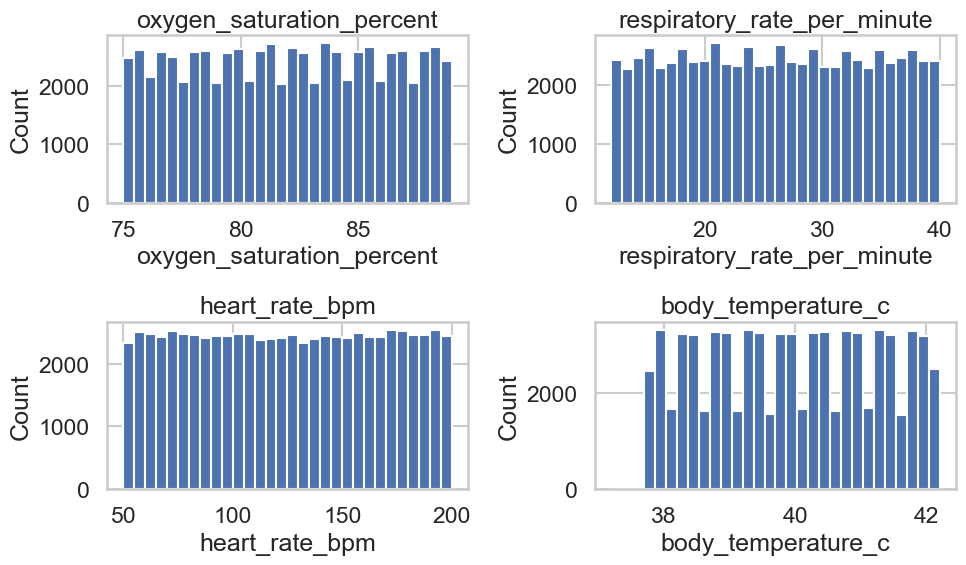

In [24]:
# 3. Create histograms (2x2 subplot)
plot_cols = ["oxygen_saturation_percent", "respiratory_rate_per_minute", "heart_rate_bpm", "body_temperature_c"]

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes = axes.ravel()

for ax, col in zip(axes, plot_cols):
    x = covid_df[col].dropna()
    ax.hist(x, bins=30)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()


**Question:** Are there any concerning values in the vital signs? What might explain extreme values?

*Your answer here:*



### Exercise 2.5: Visit Type Distribution

1. Count the number of Inpatient vs Outpatient visits
2. Calculate the percentage of each type
3. Create a pie chart or bar chart showing the distribution

Counts:
 visit_type
Outpatient Visit        134954
Inpatient Visit          20998
Emergency Room Visit        20
Name: count, dtype: int64

Percent:
 visit_type
Outpatient Visit        86.5
Inpatient Visit         13.5
Emergency Room Visit     0.0
Name: count, dtype: float64


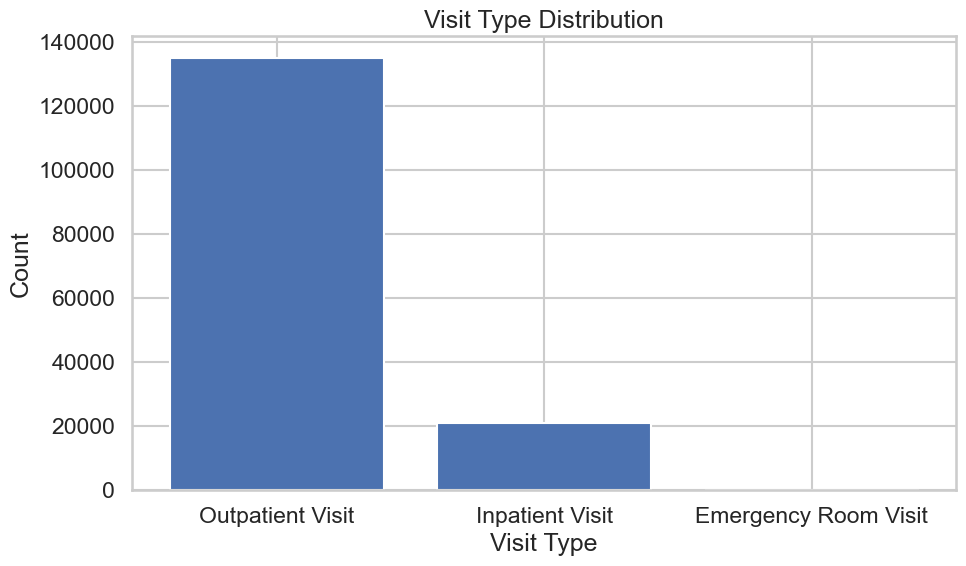

In [ ]:
visit_counts = df["visit_type"].value_counts(dropna=False)
visit_perc = (visit_counts / len(df) * 100).round(1)

print("Counts:\n", visit_counts)
print("\nPercent:\n", visit_perc)

plt.figure(figsize=(10, 6))
plt.bar(visit_counts.index.astype(str), visit_counts.values)
plt.title("Visit Type Distribution")
plt.xlabel("Visit Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### Exercise 2.6: Outlier Detection in Vital Signs

Identify potential outliers in vital sign measurements. Consider clinical validity:
- Temperature: Normal 36-37.5°C, fever >38°C, extreme >42°C
- Oxygen saturation: Normal >95%, concerning <90%, critical <80%
- Heart rate: Normal 60-100 bpm, tachycardia >100, extreme >180
- Respiratory rate: Normal 12-20/min, elevated >24, extreme >40

**Dimension focus:** Distributional exploration

In [ ]:
# Identify potential clinically implausible / extreme values (focus on COVID-suspected where vitals exist)
d = covid_df.copy()

rules = {
    "body_temperature_c": {"low": 30, "high": 42},                 # flag outside plausible human range
    "oxygen_saturation_percent": {"low": 80, "high": 100},         # critical low <80
    "heart_rate_bpm": {"low": 30, "high": 180},
    "respiratory_rate_per_minute": {"low": 5, "high": 40},
}

outlier_summary = []

for col, r in rules.items():
    if col not in d.columns:
        continue
    x = d[col]
    mask = x.notna() & ((x < r["low"]) | (x > r["high"]))
    outlier_summary.append({
        "column": col,
        "n_outliers": int(mask.sum()),
        "pct_outliers": float((mask.sum() / x.notna().sum()) * 100) if x.notna().sum() else 0.0,
        "min": float(x.min()) if x.notna().any() else np.nan,
        "max": float(x.max()) if x.notna().any() else np.nan,
    })

outlier_summary_df = pd.DataFrame(outlier_summary).sort_values("n_outliers", ascending=False)
outlier_summary_df

,column,n_outliers,pct_outliers,min,max
1,oxygen_saturation_percent,25801,35.208788,75.0,89.0
2,heart_rate_bpm,9841,13.427297,50.0,200.0
0,body_temperature_c,2497,3.407339,37.2,42.2
3,respiratory_rate_per_minute,0,0.000000,12.0,40.0
